<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).


In [1]:
# Check for GPU
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [2]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.7.1+cu126


'cpu'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.


1. Train for more epochs
2. Tweak the learning rate
3. Add more layers to model


## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.


In [ ]:
# 1. Get data
from torchvision.datasets import ImageFolder
from torchvision import transforms as T
from torch.utils.data import DataLoader
from pathlib import Path
import os


DATA_DIR = Path("data")
DATASET_DIR = DATA_DIR / "pizza_steak_sushi"
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

transforms = T.Compose([
    T.Resize(size=(64, 64)),
    T.ToTensor()
])

train_data = ImageFolder(root=TRAIN_DIR,
                         transform=transforms,
                         target_transform=None)


test_data = ImageFolder(root=TEST_DIR,
                        transform=transforms,
                        target_transform=None)

# Dataloader
train_loader = DataLoader(dataset=train_data,
                          batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS,
                          shuffle=True)

test_loader = DataLoader(dataset=test_data,
                         batch_size=BATCH_SIZE,
                         num_workers=NUM_WORKERS,
                         shuffle=False)

In [5]:
# 2. Become one with the data
import os


def walk_through_dir(dir_path):
    """Walks through dir_path returning file counts of its contents."""
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(
            f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")


walk_through_dir(DATASET_DIR)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'.


In [4]:
# Setup train and testing paths

TEST_PATH = DATASET_DIR / "test"
TRAIN_PATH = DATASET_DIR / "train"

In [17]:
# Visualize an image
from PIL import Image

images_paths = list(DATASET_DIR.glob("*/*/*.jpg"))

img = Image.open(images_paths[0])

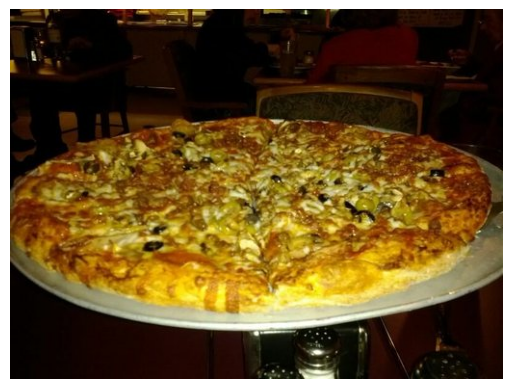

In [20]:
# Do the image visualization with matplotlib
import numpy as np
import matplotlib.pyplot as plt

img_np = np.asarray(img)

plt.imshow(img_np)
plt.axis(False)
plt.show()

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:

1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.


In [ ]:
# 3.1 Transforming data with torchvision.transforms

In [23]:
# Write transform for turning images into tensors
from torchvision import transforms as T

transforms = T.Compose([
    T.Resize(size=(64, 64)),
    T.ToTensor()
])

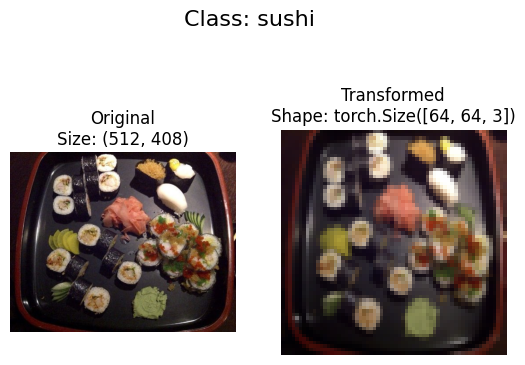

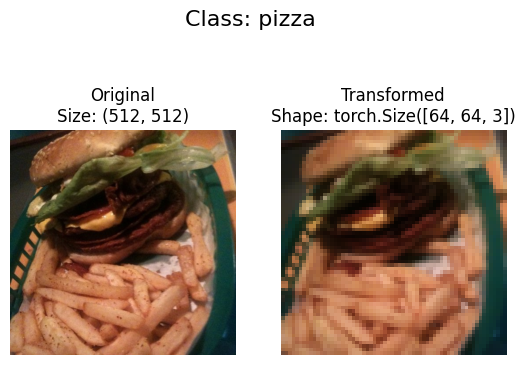

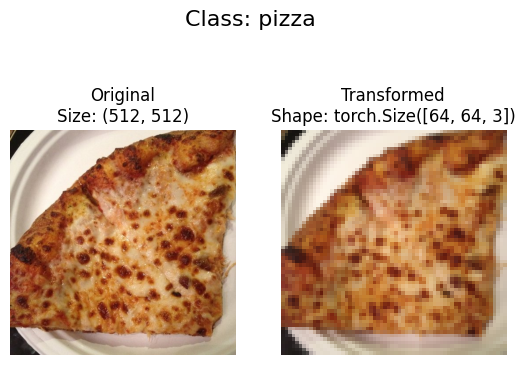

In [ ]:
# Write a function to plot transformed images
import random


def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
    """
    Selects random images from a path of images and loads/transforms then plots the original vs transformed version 
    """
    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # Transform and plot target image
            # Note: we will need to change shape for matplotlib (C, H, W) -> (H, W, C)
            transformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


plot_transformed_images(image_paths=images_paths,
                        transform=transforms,
                        n=3,
                        seed=42)

### Load image data using `ImageFolder`


In [48]:
# Use ImageFolder to create dataset(s)

train_data = ImageFolder(root=TRAIN_DIR,
                         transform=transforms,
                         target_transform=None)


test_data = ImageFolder(root=TEST_DIR,
                        transform=transforms,
                        target_transform=None)

In [49]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [50]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [51]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [52]:
# Turn train and test Datasets into DataLoaders

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_loader = DataLoader(dataset=train_data,
                          batch_size=BATCH_SIZE,
                          num_workers=NUM_WORKERS,
                          shuffle=True)

test_loader = DataLoader(dataset=test_data,
                         batch_size=BATCH_SIZE,
                         num_workers=NUM_WORKERS,
                         shuffle=False)

In [53]:
# How many batches of images are in our data loaders?
len(train_loader), len(test_loader)

(8, 3)

## 3. Recreate `model_0` we built in section 7 of notebook 04.


In [54]:

class TinyVGG(nn.Module):
    """Model architecture copying TinyVGG from CNN Explainer"""

    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units,
                      kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # default stride is same as kernel size
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units,
                      kernel_size=3, stride=1, padding=0),
            nn.ReLU(),
            # default stride is same as kernel size
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 13 *
                      13, out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifer(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x)))  # benefits from operator fusion

In [55]:
model = TinyVGG(input_shape=3, hidden_units=10,
                output_shape=len(class_names)).to(device)

## 4. Create training and testing functions for `model_0`.


In [68]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):

    # Put the model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader and data batches
    for batch, (img, label) in enumerate(dataloader):
        # Send data to target device
        img, label = img.to(device), label.to(device)
    # 1. Forward pass
        output = model(img)
    # 2. Calculate and accumulate loss
        loss = loss_fn(output, label)
        train_loss += loss

    # 3. Optimizer zero grad
        optimizer.zero_grad()
    # 4. Loss backward
        loss.backward()
    # 5. Optimizer step
        optimizer.step()
    # Calculate and accumualte accuracy metric across all batches
        pred = torch.argmax(output, dim=1)
        train_acc += (pred == label).sum().item() / sum(label)

    # Adjust metrics to get average loss and average accuracy per batch
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)

    return train_loss, train_acc

In [69]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

    # Put model in eval mode
    model.eval()

    # Setup the test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for img, label in dataloader:
            # Send data to target device
            img, label = img.to(device), label.to(device)

            # 1. Forward pass
            output = model(img)

            # 2. Calculuate and accumulate loss
            loss = loss_fn(output, label)
            test_loss += loss

            # Calculate and accumulate accuracy
            pred = torch.argmax(output, dim=1)
            test_acc += (pred == label).sum().item() / len(label)

        # Adjust metrics to get average loss and accuracy per batch
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)

    return test_loss, test_acc

In [70]:
from tqdm.auto import tqdm


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # Create results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}

    # Loop through the training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        # Train step
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        # Test step
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn)

        # Print out what's happening
        print(f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | "
              f"train_acc: {train_acc:.4f} | "
              f"test_loss: {test_loss:.4f} | "
              f"test_acc: {test_acc:.4f}"
              )

        # Update the results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # Return the results dictionary
    return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?

- Use `torch.optim.Adam()` with a learning rate of 0.001 as the optimizer.


In [71]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),
                             lr=0.001)

EPOCHS = 5

results_epoch_5 = train(model=model,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=EPOCHS)

 20%|██        | 1/5 [00:00<00:02,  1.46it/s]

Epoch: 1 | train_loss: 1.1012 | train_acc: nan | test_loss: 1.0922 | test_acc: 0.2907


 40%|████      | 2/5 [00:01<00:02,  1.44it/s]

Epoch: 2 | train_loss: 1.0766 | train_acc: inf | test_loss: 1.1100 | test_acc: 0.2604


 60%|██████    | 3/5 [00:02<00:01,  1.44it/s]

Epoch: 3 | train_loss: 1.0687 | train_acc: inf | test_loss: 1.1412 | test_acc: 0.2604


 80%|████████  | 4/5 [00:02<00:00,  1.46it/s]

Epoch: 4 | train_loss: 1.1127 | train_acc: 0.3216 | test_loss: 1.1425 | test_acc: 0.2604


100%|██████████| 5/5 [00:03<00:00,  1.45it/s]

Epoch: 5 | train_loss: 1.0727 | train_acc: inf | test_loss: 1.1428 | test_acc: 0.3021


In [73]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),  # TODO,
                             lr=0.001)

EPOCHS = 20

results_epoch_5 = train(model=model,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=EPOCHS)

  5%|▌         | 1/20 [00:00<00:13,  1.44it/s]

Epoch: 1 | train_loss: 1.0583 | train_acc: inf | test_loss: 1.0888 | test_acc: 0.2708


 10%|█         | 2/20 [00:01<00:12,  1.45it/s]

Epoch: 2 | train_loss: 1.0211 | train_acc: inf | test_loss: 1.1025 | test_acc: 0.2708


 15%|█▌        | 3/20 [00:02<00:11,  1.46it/s]

...

Epoch: 18 | train_loss: 0.7571 | train_acc: inf | test_loss: 1.0481 | test_acc: 0.4129


 95%|█████████▌| 19/20 [00:13<00:00,  1.42it/s]

Epoch: 19 | train_loss: 0.7368 | train_acc: inf | test_loss: 1.0780 | test_acc: 0.4744


100%|██████████| 20/20 [00:14<00:00,  1.42it/s]

Epoch: 20 | train_loss: 0.7745 | train_acc: 0.6634 | test_loss: 1.0412 | test_acc: 0.4432


In [74]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),  # TODO,
                             lr=0.001)

EPOCHS = 50

results_epoch_5 = train(model=model,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=EPOCHS)

  2%|▏         | 1/50 [00:00<00:35,  1.37it/s]

Epoch: 1 | train_loss: 0.7614 | train_acc: inf | test_loss: 1.1405 | test_acc: 0.4138


  4%|▍         | 2/50 [00:01<00:34,  1.38it/s]

Epoch: 2 | train_loss: 0.8025 | train_acc: inf | test_loss: 1.0598 | test_acc: 0.4337


  6%|▌         | 3/50 [00:02<00:33,  1.39it/s]

...

Epoch: 48 | train_loss: 0.2524 | train_acc: inf | test_loss: 1.8248 | test_acc: 0.5047


 98%|█████████▊| 49/50 [00:35<00:00,  1.37it/s]

Epoch: 49 | train_loss: 0.2326 | train_acc: 0.9726 | test_loss: 1.7036 | test_acc: 0.5256


100%|██████████| 50/50 [00:35<00:00,  1.39it/s]

Epoch: 50 | train_loss: 0.2115 | train_acc: inf | test_loss: 1.7850 | test_acc: 0.5256


It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.


## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?


In [ ]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_1 = TinyVGG(input_shape=3, hidden_units=20,
                  output_shape=len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.0001)

EPOCHS = 20

model_1_results = train(model=model_1,
                        train_dataloader=train_loader,
                        test_dataloader=test_loader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=EPOCHS)

  5%|▌         | 1/20 [00:00<00:16,  1.18it/s]

Epoch: 1 | train_loss: 1.0966 | train_acc: 0.4348 | test_loss: 1.1056 | test_acc: 0.1979


 10%|█         | 2/20 [00:01<00:15,  1.16it/s]

Epoch: 2 | train_loss: 1.1023 | train_acc: 0.3117 | test_loss: 1.1085 | test_acc: 0.1979


 15%|█▌        | 3/20 [00:02<00:14,  1.16it/s]

...

Epoch: 18 | train_loss: 1.0905 | train_acc: 0.3906 | test_loss: 1.0955 | test_acc: 0.3011


 95%|█████████▌| 19/20 [00:16<00:00,  1.17it/s]

Epoch: 19 | train_loss: 1.0895 | train_acc: 0.4858 | test_loss: 1.0870 | test_acc: 0.6051


100%|██████████| 20/20 [00:17<00:00,  1.17it/s]

Epoch: 20 | train_loss: 1.0811 | train_acc: 0.5825 | test_loss: 1.0760 | test_acc: 0.5739


It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.


## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?

- **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
- You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.


In [76]:
# Download 20% data for Pizza/Steak/Sushi from GitHub
import requests
import zipfile
from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

# Download pizza, steak, sushi data
with open(data_path / "pizza_steak_sushi_20_percent.zip", "wb") as f:
    request = requests.get(
        "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
    print("Downloading pizza, steak, sushi 20% data...")
    f.write(request.content)

# Unzip pizza, steak, sushi data
with zipfile.ZipFile(data_path / "pizza_steak_sushi_20_percent.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi 20% data...")
    zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


In [77]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi_20_percent'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/test'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/pizza'.
There are 0 directories and 58 images in 'data/pizza_steak_sushi_20_percent/test/steak'.
There are 0 directories and 46 images in 'data/pizza_steak_sushi_20_percent/test/sushi'.
There are 3 directories and 0 images in 'data/pizza_steak_sushi_20_percent/train'.
There are 0 directories and 154 images in 'data/pizza_steak_sushi_20_percent/train/pizza'.
There are 0 directories and 146 images in 'data/pizza_steak_sushi_20_percent/train/steak'.
There are 0 directories and 150 images in 'data/pizza_steak_sushi_20_percent/train/sushi'.


Excellent, we now have double the training and testing images...


In [78]:
# Create the train and test paths
train_data_20_percent_path = image_path / "train"
test_data_20_percent_path = image_path / "test"

train_data_20_percent_path, test_data_20_percent_path

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

In [ ]:
# Turn the 20 percent datapaths into Datasets and DataLoaders
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Create datasets
train_data_20 = ImageFolder(root=train_data_20_percent_path,
                            transform=simple_transform)

test_data_20 = ImageFolder(root=test_data_20_percent_path,
                           transform=simple_transform)

# Create dataloaders
train_loader_20 = DataLoader(dataset=train_data_20,
                             batch_size=BATCH_SIZE,
                             num_workers=NUM_WORKERS,
                             shuffle=True)

test_loader_20 = DataLoader(dataset=test_data_20,
                            batch_size=BATCH_SIZE,
                            num_workers=NUM_WORKERS,
                            shuffle=False)

In [80]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.0001)

EPOCHS = 20
model_1_results_20 = train(model=model_1,
                           train_dataloader=train_loader_20,
                           test_dataloader=test_loader_20,
                           optimizer=optimizer,
                           loss_fn=loss_fn,
                           epochs=EPOCHS)

  5%|▌         | 1/20 [00:01<00:23,  1.25s/it]

Epoch: 1 | train_loss: 1.0815 | train_acc: 0.4982 | test_loss: 1.0761 | test_acc: 0.4841


 10%|█         | 2/20 [00:02<00:23,  1.29s/it]

Epoch: 2 | train_loss: 1.0699 | train_acc: 0.5641 | test_loss: 1.0664 | test_acc: 0.4955


 15%|█▌        | 3/20 [00:04<00:23,  1.38s/it]

...

Epoch: 18 | train_loss: 0.8209 | train_acc: 0.6629 | test_loss: 0.8585 | test_acc: 0.5670


 95%|█████████▌| 19/20 [00:24<00:01,  1.27s/it]

Epoch: 19 | train_loss: 0.8968 | train_acc: 0.6045 | test_loss: 0.8483 | test_acc: 0.6222


100%|██████████| 20/20 [00:26<00:00,  1.31s/it]

Epoch: 20 | train_loss: 0.8290 | train_acc: 0.6159 | test_loss: 0.8449 | test_acc: 0.6188


## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction.

- Does the model you trained in exercise 7 get it right?
- If not, what do you think you could do to improve it?


In [ ]:
img_pred_path = DATA_DIR / "04-pizza-dad.jpeg"
img = Image.open(img_pred_path)

img_input = simple_transform(img)
img_input.shape

torch.Size([3, 64, 64])

In [ ]:
# Adding batch size
img_input_batch = img_input.unsqueeze(dim=0)
img_input_batch.shape

torch.Size([1, 3, 64, 64])

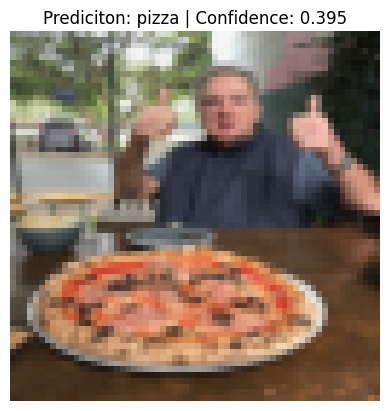

In [97]:
model_1.eval()
with torch.inference_mode():
    output = model_1(img_input_batch)
    probs = torch.softmax(output, dim=1)
    confidence = torch.max(probs)
    pred = torch.argmax(probs, dim=1)


plt.title(f"Prediciton: {class_names[pred]} | Confidence: {confidence:.3f}")
plt.imshow(img_input.permute(1, 2, 0))
plt.axis(False)
plt.show()